# Wind and solar generation in Germany
Exploration of the Energy-Charts `public_power` sample (20–21 Sept 2026), values in MW.

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

data = json.loads(Path("../data/samples/public_power.json").read_text())

In [3]:
wanted = ["Wind onshore", "Wind offshore", "Solar"]
df = pd.DataFrame({"unix_seconds": data["unix_seconds"]})
for item in data["production_types"]:
    if item["name"] in wanted:
        df[item["name"]] = item["data"]

df["timestamp_berlin"] = (
    pd.to_datetime(df["unix_seconds"], unit="s", utc=True)
    .dt.tz_convert("Europe/Berlin")
)
df.head(10)

,unix_seconds,Wind offshore,Wind onshore,Solar,timestamp_berlin
0,1789855200,3534.6,30583.2,0.0,2026-09-20 00:00:00+02:00
1,1789856100,3614.1,30630.8,0.0,2026-09-20 00:15:00+02:00
2,1789857000,3572.0,30443.0,0.0,2026-09-20 00:30:00+02:00
3,1789857900,3591.1,29902.7,0.0,2026-09-20 00:45:00+02:00
4,1789858800,3669.0,29226.7,0.0,2026-09-20 01:00:00+02:00
5,1789859700,3757.0,28575.0,0.0,2026-09-20 01:15:00+02:00
6,1789860600,3831.1,28293.9,0.0,2026-09-20 01:30:00+02:00
7,1789861500,3881.1,28063.6,0.0,2026-09-20 01:45:00+02:00
8,1789862400,3711.0,27521.9,0.0,2026-09-20 02:00:00+02:00
9,1789863300,3748.2,27096.0,0.0,2026-09-20 02:15:00+02:00


In [4]:
df[wanted].describe()

,Wind onshore,Wind offshore,Solar
count,192.000000,192.000000,192.000000
mean,24898.629167,2910.921875,9227.377604
std,5481.207168,1273.280010,12176.880320
min,10904.200000,1070.000000,0.000000
25%,22157.150000,1796.150000,0.000000
50%,24810.350000,2809.550000,238.600000
75%,28778.325000,4200.950000,19218.650000
max,38152.000000,5262.200000,36814.400000


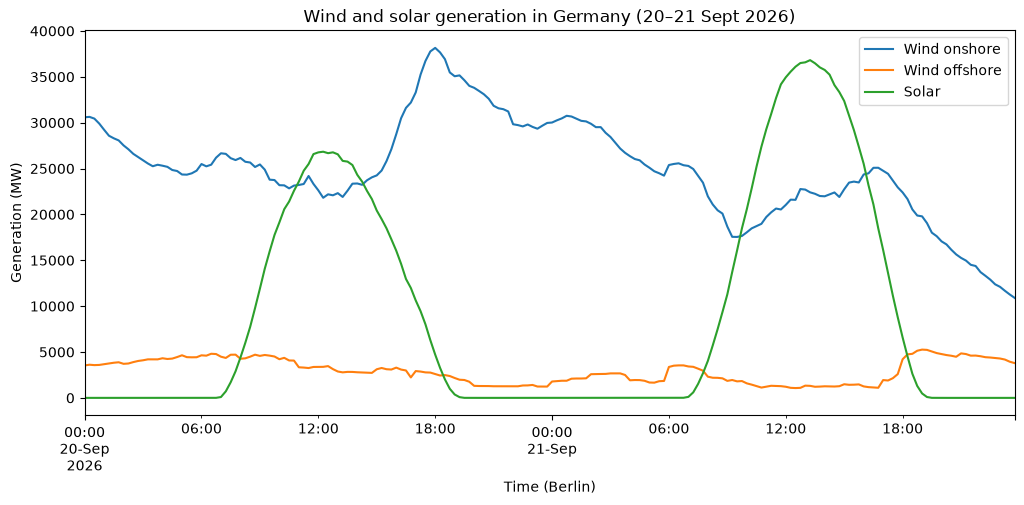

In [5]:
ax = df.set_index("timestamp_berlin")[wanted].plot(figsize=(12, 5))
ax.set_title("Wind and solar generation in Germany (20–21 Sept 2026)")
ax.set_xlabel("Time (Berlin)")
ax.set_ylabel("Generation (MW)")
plt.show()

In [6]:
df.loc[df["Solar"].idxmax()]

unix_seconds                       1789989300
Wind offshore                          1312.0
Wind onshore                          22405.1
Solar                                 36814.4
timestamp_berlin    2026-09-21 13:15:00+02:00
Name: 149, dtype: object